In [37]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\PALLAVI PUNDE\Downloads\cardekho_dataset.csv\cardekho_dataset.csv"
)

df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [38]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (15411, 14)

Column Names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Data Types:
Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

Missing Values:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtyp

In [39]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [40]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [41]:
print("Fuel Types:")
print(df["fuel_type"].unique())

print("\nTransmission Types:")
print(df["transmission_type"].unique())

print("\nSeller Types:")
print(df["seller_type"].unique())

Fuel Types:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

Transmission Types:
['Manual' 'Automatic']

Seller Types:
['Individual' 'Dealer' 'Trustmark Dealer']


In [42]:
print("Minimum Selling Price:", df["selling_price"].min())
print("Maximum Selling Price:", df["selling_price"].max())
print("Average Selling Price:", df["selling_price"].mean())

Minimum Selling Price: 40000
Maximum Selling Price: 39500000
Average Selling Price: 774971.1164103562


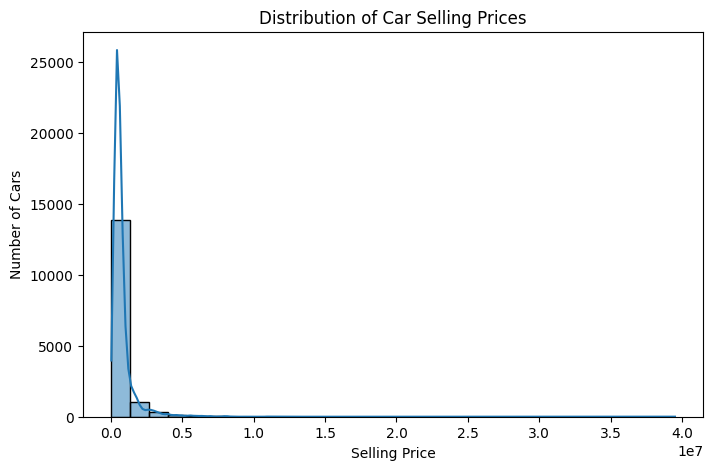

In [43]:
# Selling price distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df["selling_price"], bins=30, kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

In [44]:
# Remove unnecessary column
# Remove unnecessary index column
df = df.drop("Unnamed: 0", axis=1)

# Check the columns again
print(df.columns.tolist())

['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [45]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 167


In [46]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (15244, 13)


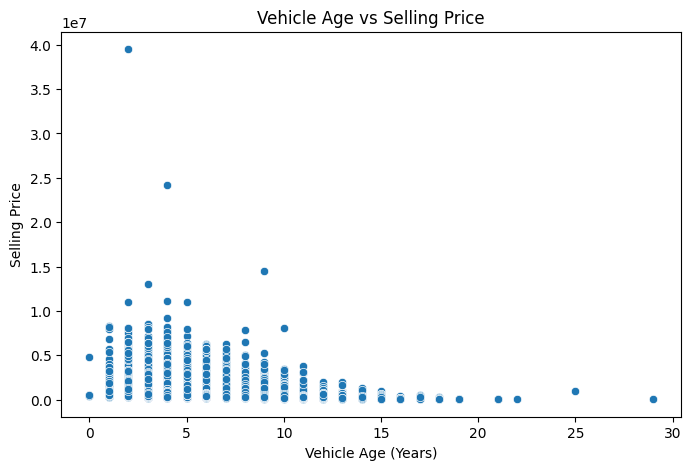

In [47]:
# EDA: Price vs Vehicle Age
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="vehicle_age",
    y="selling_price"
)

plt.title("Vehicle Age vs Selling Price")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Selling Price")

plt.show()

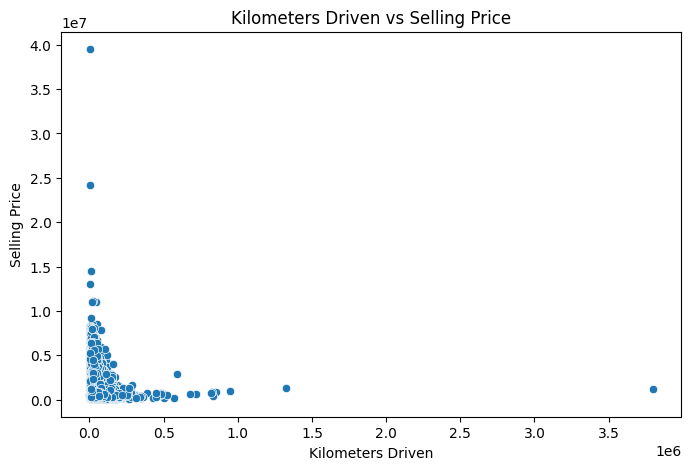

In [48]:
# Price vs Kilometers Driven
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="km_driven",
    y="selling_price"
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.show()

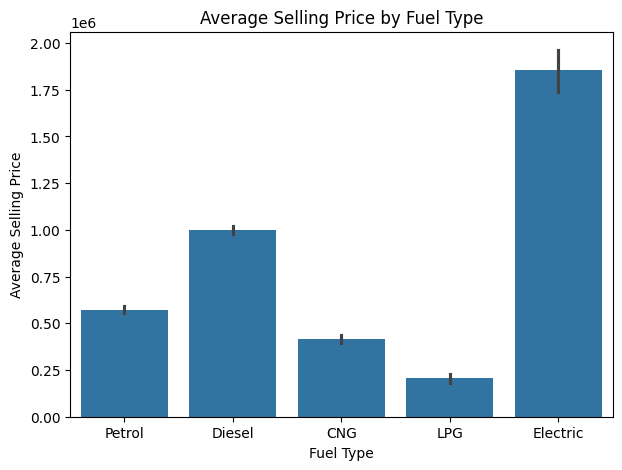

In [49]:
# Average price by fuel type
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="fuel_type",
    y="selling_price"
)

plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")

plt.show()

In [50]:
# Separate input features and target variable

X = df.drop("selling_price", axis=1)
y = df["selling_price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (15244, 12)
Target shape: (15244,)


In [51]:
# Find categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns

# Find numerical columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

print("\nNumerical Columns:")
print(numerical_cols.tolist())

Categorical Columns:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Numerical Columns:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']


In [52]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (12195, 12)
Testing data: (3049, 12)


In [53]:
# One-Hot Encoding + Model Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully!")


Preprocessor created successfully!


In [54]:
# model training stage
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Create Random Forest pipeline
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [55]:
# Predict car prices
y_pred_rf = rf_model.predict(X_test)

print("Predictions completed!")
print("First 10 predicted prices:")
print(y_pred_rf[:10])

Predictions completed!
First 10 predicted prices:
[ 566948.57142857  347446.66666667  798476.66666667 6050709.16666667
  631720.          557460.          240320.          964390.
  634945.          554307.66666667]


In [56]:
# Evaluate Random Forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R² Score:", round(r2_rf, 4))

Random Forest Results
---------------------
MAE : 99760.26
RMSE: 251813.29
R² Score: 0.8957


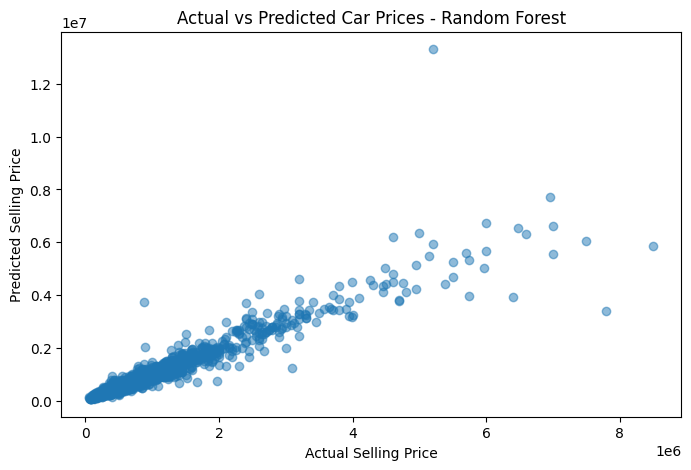

In [57]:
# Actual vs Predicted graph
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices - Random Forest")

plt.show()

In [58]:
# Second model: Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [59]:
# Predict with Gradient Boosting
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting predictions completed!")

Gradient Boosting predictions completed!


In [60]:
# Evaluate Gradient Boosting
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", round(mae_gb, 2))
print("RMSE:", round(rmse_gb, 2))
print("R² Score:", round(r2_gb, 4))

Gradient Boosting Results
-------------------------
MAE : 124086.44
RMSE: 292989.57
R² Score: 0.8588


In [61]:
# Compare both models
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_rf,
        rmse_gb
    ],
    "R2 Score": [
        r2_rf,
        r2_gb
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,99760.255395,251813.293459,0.895711
1,Gradient Boosting,124086.438069,292989.573588,0.858816


In [62]:
# Find the best model
if r2_rf > r2_gb:
    print("Best Model: Random Forest")
    print("Best R² Score:", round(r2_rf, 4))
else:
    print("Best Model: Gradient Boosting")
    print("Best R² Score:", round(r2_gb, 4))

Best Model: Random Forest
Best R² Score: 0.8957


In [63]:
# Predict the price of a new car
if r2_rf > r2_gb:
    best_model = rf_model
    best_model_name = "Random Forest"
else:
    best_model = gb_model
    best_model_name = "Gradient Boosting"

print("Selected Best Model:", best_model_name)

Selected Best Model: Random Forest


In [64]:
# create sample car
new_car = pd.DataFrame({
    "car_name": ["Maruti Alto"],
    "brand": ["Maruti"],
    "model": ["Alto"],
    "vehicle_age": [5],
    "km_driven": [30000],
    "seller_type": ["Individual"],
    "fuel_type": ["Petrol"],
    "transmission_type": ["Manual"],
    "mileage": [20.0],
    "engine": [998],
    "max_power": [67.1],
    "seats": [5]
})

new_car

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Maruti Alto,Maruti,Alto,5,30000,Individual,Petrol,Manual,20.0,998,67.1,5


In [65]:
# Predict selling price
predicted_price = best_model.predict(new_car)[0]

print("Predicted Car Selling Price: ₹", round(predicted_price, 2))

Predicted Car Selling Price: ₹ 306121.67


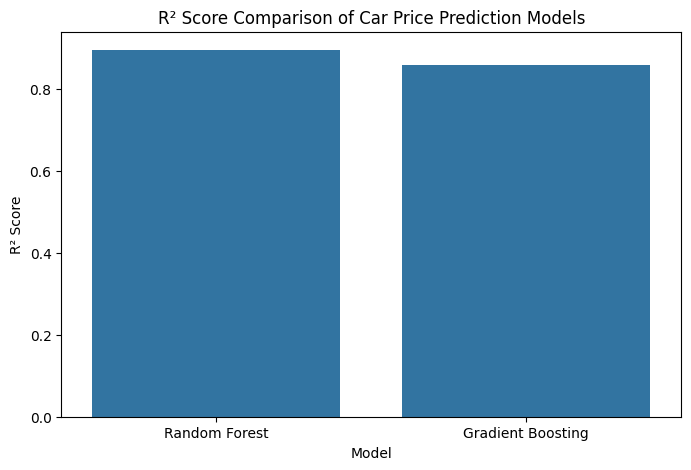

In [66]:
# Final model comparison chart
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.title("R² Score Comparison of Car Price Prediction Models")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()